deep diving to a specific roi - how birth year affects it in different generations
age windows - fixed on 5 years

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from pygam import LinearGAM, s, f


# helper functions

### modeling the roi volume change (linear/quad/GAM)

In [2]:


def analyze_roi_lifespan(roi_id, full_df, age_windows, min_samples=20, show_plots=True):
    """
    Performs model selection (Linear vs Quadratic vs GAM) across multiple age windows
    for a single ROI.
    """
    roi_results = []
    roi_df_full = full_df[full_df['region_label'] == roi_id].copy()
    
    # Pre-calculate formulas
    f_lin = 'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years'
    f_quad = 'volume_mm3 ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years'

    for min_age, max_age in age_windows:
        mask = (roi_df_full['age_in_years'] >= min_age) & (roi_df_full['age_in_years'] <= max_age)
        filtered_df = roi_df_full[mask].copy()
        
        if len(filtered_df) < min_samples:
            continue 

        # --- 1. Fit Models ---
        m_lin = smf.ols(f_lin, data=filtered_df).fit()
        m_quad = smf.ols(f_quad, data=filtered_df).fit()

        # Prepare for GAM
        filtered_df['sex_code'] = pd.Categorical(filtered_df['sex']).codes
        X_gam = filtered_df[['birth_year', 'sex_code', 'tiv', 'age_in_years']].values
        y_gam = filtered_df['volume_mm3'].values
        m_gam = LinearGAM(s(0) + f(1) + s(2) + s(3)).fit(X_gam, y_gam)

        # --- 2. Model Selection (AIC) ---
        try:
            gam_aic = m_gam.statistics_['AIC']
            gam_r2 = m_gam.statistics_['pseudo_r2']
        except:
            gam_aic, gam_r2 = np.inf, 0

        aics = {'Linear': m_lin.aic, 'Quadratic': m_quad.aic, 'GAM': gam_aic}
        best_label = min(aics, key=aics.get)
        
        # --- 3. Feature Extraction (Vertex) ---
        vertex_x = np.nan
        if best_label == "Quadratic":
            a, b = m_quad.params.get('I(birth_year ** 2)'), m_quad.params.get('birth_year')
            if a and a != 0: vertex_x = -b / (2 * a)
        elif best_label == "GAM":
            by_grid = np.linspace(filtered_df['birth_year'].min(), filtered_df['birth_year'].max(), 500)
            X_pred = np.column_stack([
                by_grid,
                np.full_like(by_grid, filtered_df['sex_code'].mode()[0]),
                np.full_like(by_grid, filtered_df['tiv'].mean()),
                np.full_like(by_grid, filtered_df['age_in_years'].mean())
            ])
            y_preds = m_gam.predict(X_pred)
            vertex_x = by_grid[np.argmax(y_preds)] if (y_preds.max() - y_preds[0] > 0) else by_grid[np.argmin(y_preds)]

        # --- 4. Store Results ---
        r2 = m_lin.rsquared_adj if best_label == 'Linear' else (m_quad.rsquared_adj if best_label == 'Quadratic' else gam_r2)
        roi_results.append({
            'roi': roi_id,
            'age_window': f"{min_age}-{max_age}",
            'best_model': best_label,
            'aic_lin': m_lin.aic, 'aic_quad': m_quad.aic, 'aic_gam': gam_aic,
            'vertex_x': vertex_x, 'r2_adj': r2,
            'n_samples': len(filtered_df)
        })

        # --- 5. Plotting ---
        if show_plots:
            plot_best_fit(filtered_df, m_lin, m_quad, m_gam, best_label, vertex_x, roi_id, min_age, max_age)

    return roi_results

def plot_best_fit(df, m_lin, m_quad, m_gam, best_label, vertex, roi, min_a, max_a):
    fig, ax = plt.subplots(figsize=(7, 4))
    by_range = np.linspace(df['birth_year'].min(), df['birth_year'].max(), 100)
    
    if best_label in ['Linear', 'Quadratic']:
        mod = m_lin if best_label == 'Linear' else m_quad
        pred_df = pd.DataFrame({
            'birth_year': by_range, 'sex': df['sex'].mode()[0],
            'tiv': df['tiv'].mean(), 'age_in_years': df['age_in_years'].mean()
        })
        preds = mod.get_prediction(pred_df).summary_frame()
        y_m, y_l, y_h = preds['mean'], preds['mean_ci_lower'], preds['mean_ci_upper']
    else:
        X_p = np.column_stack([by_range, np.full_like(by_range, df['sex_code'].mode()[0]),
                               np.full_like(by_range, df['tiv'].mean()), np.full_like(by_range, df['age_in_years'].mean())])
        y_m = m_gam.predict(X_p)
        conf = m_gam.confidence_intervals(X_p)
        y_l, y_h = conf[:, 0], conf[:, 1]

    ax.scatter(df['birth_year'], df['volume_mm3'], alpha=0.3, c='gray', s=10)
    ax.plot(by_range, y_m, color='crimson', lw=2, label=f'Best: {best_label}')
    ax.fill_between(by_range, y_l, y_h, color='crimson', alpha=0.15)
    if not np.isnan(vertex):
        ax.axvline(vertex, color='blue', ls='--', alpha=0.5, label='Extreme Pt')
    ax.set(title=f"ROI {roi} ({min_a}-{max_a}y)", xlabel="Birth Year", ylabel="Volume")
    ax.legend()
    plt.show()

# --- Example Usage ---
# all_results = []
# for roi in roi_list:
#     all_results.extend(analyze_roi_lifespan(roi, combined_df, age_windows))


import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pygam import LinearGAM, s, f
import matplotlib.pyplot as plt

def analyze_roi_lifespan_standardized(roi_id, full_df, age_windows, min_samples=20, show_plots=True):
    """
    Performs model selection (Linear vs Quadratic vs GAM) on Z-scored brain volumes.
    Centering is done per ROI to show trends in Standard Deviations.
    """
    roi_results = []
    
    # 1. Filter and Center the volume (Z-score)
    roi_df_full = full_df[full_df['region_label'] == roi_id].copy()
    
    # Calculate mean and SD for this specific ROI
    roi_mean = roi_df_full['volume_mm3'].mean()
    roi_std = roi_df_full['volume_mm3'].std()
    
    # Create the standardized column: (Value - Mean) / SD
    roi_df_full['volume_z'] = (roi_df_full['volume_mm3'] - roi_mean) / roi_std
    
    # Updated formulas using 'volume_z'
    f_lin = 'volume_z ~ birth_year + C(sex) + tiv + age_in_years'
    f_quad = 'volume_z ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years'

    for min_age, max_age in age_windows:
        mask = (roi_df_full['age_in_years'] >= min_age) & (roi_df_full['age_in_years'] <= max_age)
        filtered_df = roi_df_full[mask].copy()
        
        if len(filtered_df) < min_samples:
            continue 

        # --- Fit Models ---
        m_lin = smf.ols(f_lin, data=filtered_df).fit()
        m_quad = smf.ols(f_quad, data=filtered_df).fit()

        # GAM Preparation
        filtered_df['sex_code'] = pd.Categorical(filtered_df['sex']).codes
        X_gam = filtered_df[['birth_year', 'sex_code', 'tiv', 'age_in_years']].values
        y_gam = filtered_df['volume_z'].values # Using standardized y
        m_gam = LinearGAM(s(0) + f(1) + s(2) + s(3)).fit(X_gam, y_gam)

        # --- Model Selection (AIC) ---
        try:
            gam_aic = m_gam.statistics_['AIC']
            gam_r2 = m_gam.statistics_['pseudo_r2']
        except:
            gam_aic, gam_r2 = np.inf, 0

        aics = {'Linear': m_lin.aic, 'Quadratic': m_quad.aic, 'GAM': gam_aic}
        best_label = min(aics, key=aics.get)
        
        # --- Feature Extraction (Vertex) ---
        vertex_x = np.nan
        if best_label == "Quadratic":
            a, b = m_quad.params.get('I(birth_year ** 2)'), m_quad.params.get('birth_year')
            if a and a != 0: vertex_x = -b / (2 * a)
        elif best_label == "GAM":
            by_grid = np.linspace(filtered_df['birth_year'].min(), filtered_df['birth_year'].max(), 500)
            X_pred = np.column_stack([
                by_grid,
                np.full_like(by_grid, filtered_df['sex_code'].mode()[0]),
                np.full_like(by_grid, filtered_df['tiv'].mean()),
                np.full_like(by_grid, filtered_df['age_in_years'].mean())
            ])
            y_preds = m_gam.predict(X_pred)
            vertex_x = by_grid[np.argmax(y_preds)] if (y_preds.max() - y_preds[0] > 0) else by_grid[np.argmin(y_preds)]

        # --- Store Results ---
        roi_results.append({
            'roi': roi_id,
            'age_window': f"{min_age}-{max_age}",
            'best_model': best_label,
            'vertex_x': vertex_x,
            'r2_adj': m_lin.rsquared_adj if best_label == 'Linear' else (m_quad.rsquared_adj if best_label == 'Quadratic' else gam_r2),
            'roi_mean_raw': roi_mean,
            'roi_std_raw': roi_std
        })

        if show_plots:
            plot_standardized_fit(filtered_df, m_lin, m_quad, m_gam, best_label, vertex_x, roi_id, min_age, max_age)

    return roi_results

def plot_standardized_fit(df, m_lin, m_quad, m_gam, best_label, vertex, roi, min_a, max_a):
    fig, ax = plt.subplots(figsize=(7, 4))
    by_range = np.linspace(df['birth_year'].min(), df['birth_year'].max(), 100)
    
    if best_label in ['Linear', 'Quadratic']:
        mod = m_lin if best_label == 'Linear' else m_quad
        pred_df = pd.DataFrame({
            'birth_year': by_range, 'sex': df['sex'].mode()[0],
            'tiv': df['tiv'].mean(), 'age_in_years': df['age_in_years'].mean()
        })
        preds = mod.get_prediction(pred_df).summary_frame()
        y_m, y_l, y_h = preds['mean'], preds['mean_ci_lower'], preds['mean_ci_upper']
    else:
        X_p = np.column_stack([by_range, np.full_like(by_range, df['sex_code'].mode()[0]),
                               np.full_like(by_range, df['tiv'].mean()), np.full_like(by_range, df['age_in_years'].mean())])
        y_m = m_gam.predict(X_p)
        conf = m_gam.confidence_intervals(X_p)
        y_l, y_h = conf[:, 0], conf[:, 1]

    ax.scatter(df['birth_year'], df['volume_z'], alpha=0.3, c='gray', s=10)
    ax.plot(by_range, y_m, color='crimson', lw=2, label=f'Best: {best_label}')
    ax.fill_between(by_range, y_l, y_h, color='crimson', alpha=0.15)
    
    # Add a horizontal line at 0 (the ROI mean)
    ax.axhline(0, color='black', lw=1, ls=':', label='ROI Mean')
    
    if not np.isnan(vertex):
        ax.axvline(vertex, color='blue', ls='--', alpha=0.5, label='Extreme Pt')
    
    ax.set(title=f"Change in ROI {roi} volume along birth years in age window ({min_a}-{max_a}y)", 
           xlabel="Birth Year", 
           ylabel="Volume (Z-score / SD units)")
    ax.legend()
    plt.show()

# configuration

In [3]:
# load data
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

In [4]:
age_windows = [(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64)] # , (65,100)

# top 5 interesting rois according to the previous analysis:
roi_list = [421, 422, 237, 414, 409]

# Settings
MIN_SAMPLES = 20
alpha_level = 0.05
all_stats = []

# runs

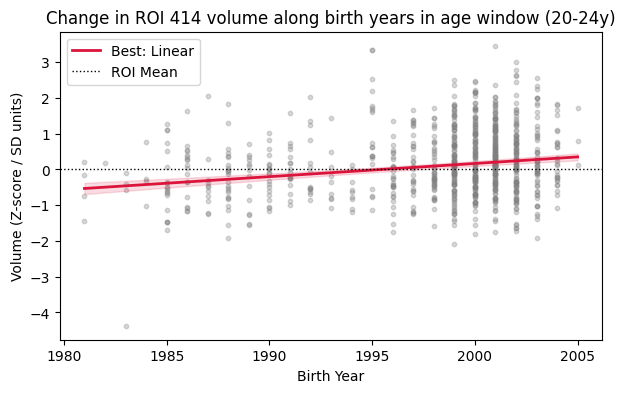

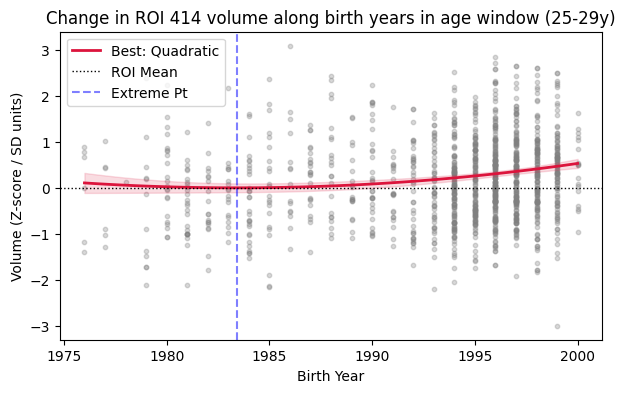

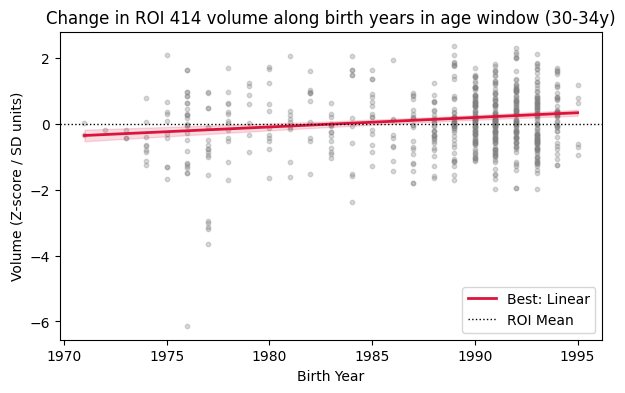

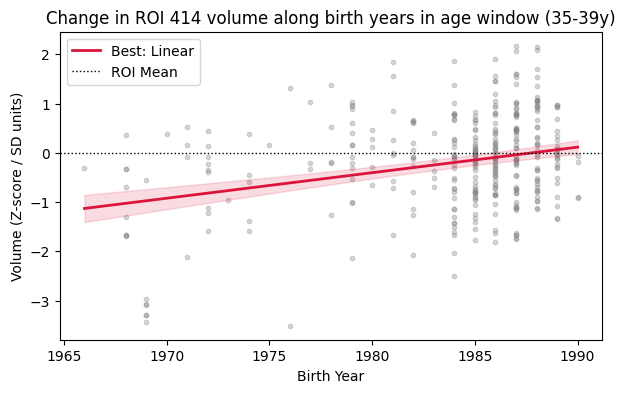

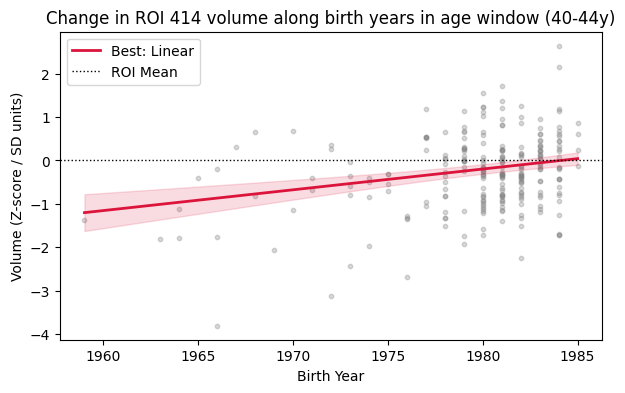

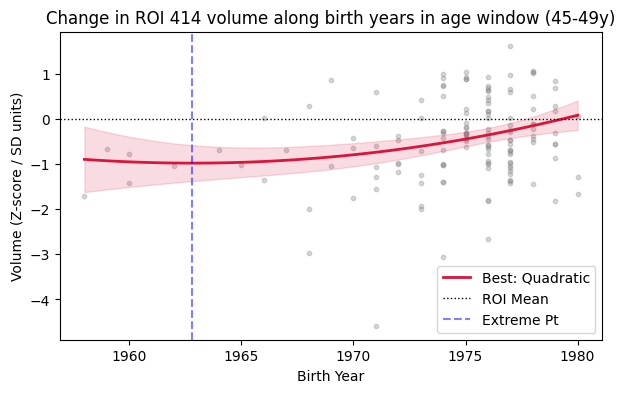

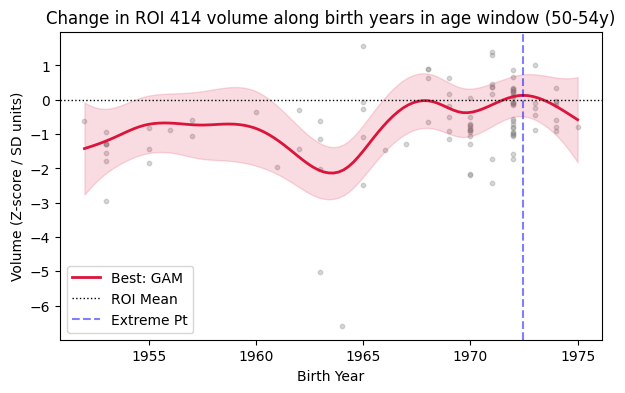

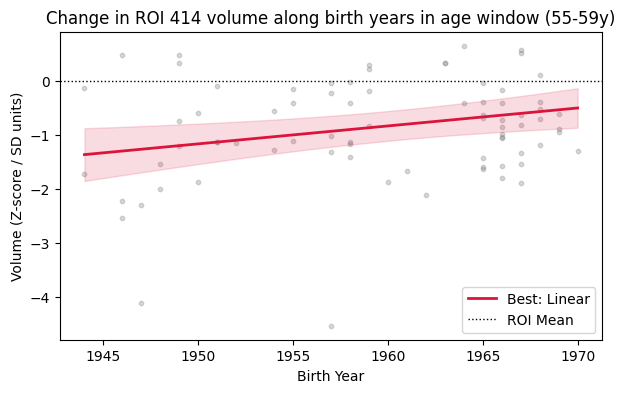

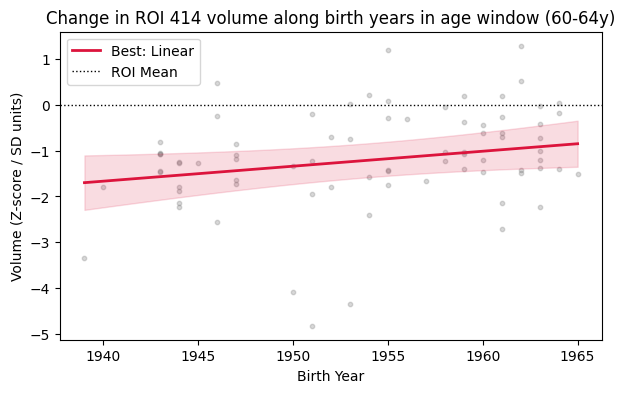

In [5]:
all_results = []
amygdala_results = analyze_roi_lifespan_standardized(414, combined_df, age_windows)


### modeling (linear/quad/GAM) the volume change in each age window (non-overlapping). Plotting birth year+ median of age window to see what events might cause the change

In [6]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pygam import LinearGAM, s, f
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def analyze_roi_flexible(roi_id, full_df, age_windows, norm_type='window', min_samples=20):
    """
    norm_type: 
      'global' -> Z-score relative to the entire ROI population.
      'window' -> Z-score relative ONLY to the people in that age bracket.
      'none'   -> Raw mm3 volumes.
    """
    roi_df = full_df[full_df['region_label'] == roi_id].copy()
    
    # Pre-calculate Global Z-score if needed
    if norm_type == 'global':
        m, s_dev = roi_df['volume_mm3'].mean(), roi_df['volume_mm3'].std()
        roi_df['target_y'] = (roi_df['volume_mm3'] - m) / s_dev
    elif norm_type == 'none':
        roi_df['target_y'] = roi_df['volume_mm3']

    window_results = []

    for min_a, max_a in age_windows:
        mask = (roi_df['age_in_years'] >= min_a) & (roi_df['age_in_years'] <= max_a)
        sub_df = roi_df[mask].copy()
        
        if len(sub_df) < min_samples:
            continue

        # Per-Window Normalization logic
        if norm_type == 'window':
            m_win, s_win = sub_df['volume_mm3'].mean(), sub_df['volume_mm3'].std()
            sub_df['target_y'] = (sub_df['volume_mm3'] - m_win) / s_win
        
        # Define formulas dynamically
        f_lin = 'target_y ~ birth_year + C(sex) + tiv + age_in_years'
        f_quad = 'target_y ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years'

        # --- Model Selection ---
        # 1. Statsmodels fits
        m_lin = smf.ols(f_lin, data=sub_df).fit()
        m_quad = smf.ols(f_quad, data=sub_df).fit()

        # 2. GAM fit
        sub_df['sex_code'] = pd.Categorical(sub_df['sex']).codes
        X_gam = sub_df[['birth_year', 'sex_code', 'tiv', 'age_in_years']].values
        y_gam = sub_df['target_y'].values
        try:
            m_gam = LinearGAM(s(0) + f(1) + s(2) + s(3)).fit(X_gam, y_gam)
            gam_aic = m_gam.statistics_['AIC']
        except:
            gam_aic = np.inf

        # 3. Choose Best
        aics = {'Linear': m_lin.aic, 'Quadratic': m_quad.aic, 'GAM': gam_aic}
        best_label = min(aics, key=aics.get)
        best_mod = {'Linear': m_lin, 'Quadratic': m_quad, 'GAM': m_gam}[best_label]

        # --- Generate Prediction Line ---
        by_range = np.linspace(sub_df['birth_year'].min(), sub_df['birth_year'].max(), 100)
        median_age = (min_a + max_a) / 2
        
        if best_label == 'GAM':
            X_p = np.column_stack([by_range, 
                                   np.full_like(by_range, sub_df['sex_code'].mode()[0]),
                                   np.full_like(by_range, sub_df['tiv'].mean()), 
                                   np.full_like(by_range, sub_df['age_in_years'].mean())])
            y_preds = best_mod.predict(X_p)
        else:
            pred_df = pd.DataFrame({
                'birth_year': by_range, 'sex': sub_df['sex'].mode()[0],
                'tiv': sub_df['tiv'].mean(), 'age_in_years': sub_df['age_in_years'].mean()
            })
            y_preds = best_mod.predict(pred_df).values

        window_results.append({
            'age_label': f"{min_a}-{max_a}",
            'x_shifted': by_range + median_age,
            'y_preds': y_preds,
            'best_model': best_label
        })
        
    return window_results

def plot_unified(roi_id, results, norm_type):
    plt.figure(figsize=(10, 6))
    colors = cm.viridis(np.linspace(0, 1, len(results)))
    
    for i, res in enumerate(results):
        plt.plot(res['x_shifted'], res['y_preds'], color=colors[i], lw=2, label=res['age_label'])
    
    ylabel = {
        'window': "Z-score (Relative to Age Window Mean)",
        'global': "Z-score (Relative to ROI Mean)",
        'none': "Volume (mm3)"
    }[norm_type]

    plt.title(f"Change in ROI {roi_id} Volume in all ages | Normalization per {norm_type}")
    plt.xlabel("Birth Year + Median Age")
    plt.ylabel(ylabel)
    plt.legend(title="Age Windows", bbox_to_anchor=(1,1))
    plt.grid(alpha=0.2)
    plt.show()



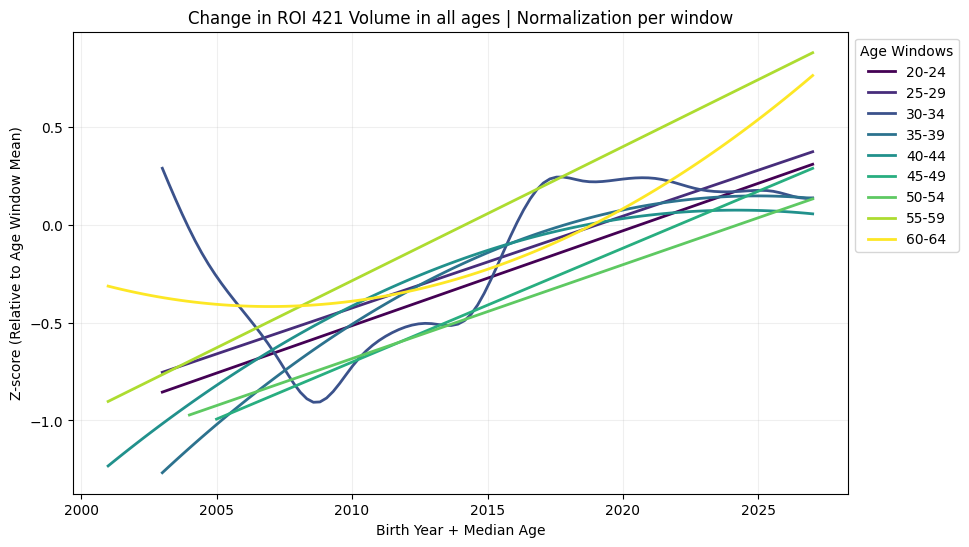

In [7]:
# Usage:
res = analyze_roi_flexible(421, combined_df, age_windows, norm_type='window')
plot_unified(421, res, 'window')

### modeling the linear model beta coefficients of birth year (overlapping windows) 

In [8]:
import numpy as np
import pandas as pd
import re
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

def model_coefficient_trend(df, roi_label, show_plot=True):
    # 1. Filter for ROI and Variable
    roi_data = df[(df['region_label'] == roi_label) & 
                  (df['variable'].str.contains('birth_year', case=False))].copy()
    
    if roi_data.empty:
        return None, None

    # 2. Regex Parser for "W00_Age_20.0-25.0"
    def extract_center(bin_str):
        nums = re.findall(r"\d+\.\d+|\d+", str(bin_str))
        if len(nums) >= 2:
            return (float(nums[-2]) + float(nums[-1])) / 2
        return np.nan

    roi_data['age_center'] = roi_data['bin'].apply(extract_center)
    roi_data = roi_data.dropna(subset=['age_center', 'coef']).sort_values('age_center')

    # --- THE FIX FOR THE VALUEERROR ---
    # Ensure X, y, and weights are all flattened 1D arrays
    X = roi_data['age_center'].values.reshape(-1, 1) # X must be 2D for GAM
    y = roi_data['coef'].values.flatten()           # y must be 1D
    w = roi_data['n_subjects'].values.flatten()    # weights MUST be 1D
    # ----------------------------------

    # 3. Model 1: GAM (The non-linear trend)
    try:
        n_splines = min(10, len(y) // 2)
        gam = LinearGAM(s(0, n_splines=max(4, n_splines))).fit(X, y, weights=w)
        x_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_gam = gam.predict(x_grid)
        ci = gam.confidence_intervals(x_grid)
    except Exception as e:
        print(f"GAM failed: {e}")
        return None, None

    # 4. Model 2: Linear Trend (Simple Slope)
    # Using WLS (Weighted Least Squares) to account for n_subjects
    X_lin = sm.add_constant(roi_data['age_center'])
    lin_mod = sm.WLS(y, X_lin, weights=w).fit()
    y_lin = lin_mod.predict(sm.add_constant(x_grid))

    # 5. Plotting
    if show_plot:
        plt.figure(figsize=(10, 6))
        
        # Data points
        plt.scatter(roi_data['age_center'], y, s=w/2, alpha=0.2, color='gray', label='Bin Coefs')
        
        # GAM Trend
        plt.plot(x_grid, y_gam, color='crimson', lw=3, label='Non-Linear (GAM)')
        plt.fill_between(x_grid.flatten(), ci[:, 0], ci[:, 1], color='crimson', alpha=0.1)
        
        # Linear Trend
        plt.plot(x_grid, y_lin, color='blue', lw=2, ls='--', label=f'Linear Slope (p={lin_mod.pvalues.iloc[1]:.3f})')
        
        plt.axhline(0, color='black', lw=1)
        plt.title(f"Evolution of Birth Year Effect: {roi_label}")
        plt.xlabel("Age (Window Center)")
        plt.ylabel("Birth Year Coefficient (Beta)")
        plt.legend()
        plt.show()

    return gam, lin_mod

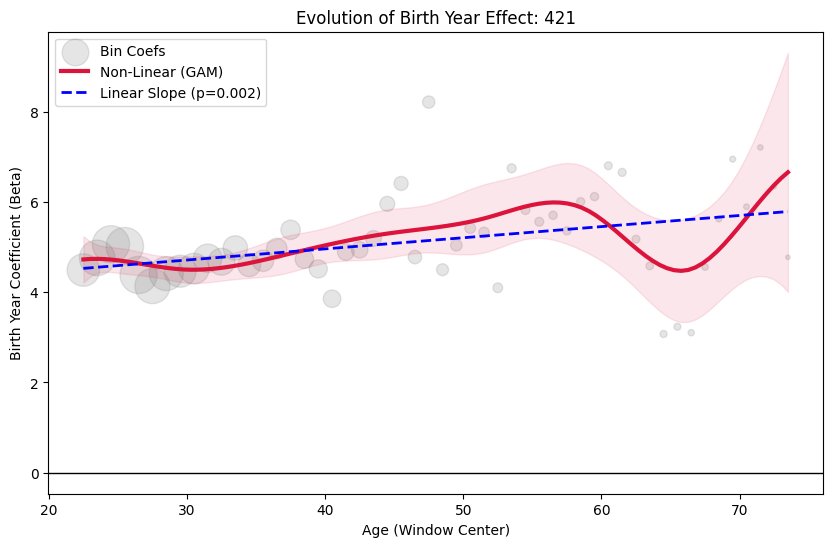

                 bin  age_interval  age_median
0  W00_Age_20.0-25.0  [20.0, 25.0)        22.5
1  W00_Age_20.0-25.0  [20.0, 25.0)        22.5
2  W00_Age_20.0-25.0  [20.0, 25.0)        22.5
3  W00_Age_20.0-25.0  [20.0, 25.0)        22.5
4  W00_Age_20.0-25.0  [20.0, 25.0)        22.5


In [12]:
# Example Usage:
coef_df = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_sliding_wy5_sy1.csv")
gam_model, processed_df = model_coefficient_trend(coef_df, 421, show_plot=True)

import pandas as pd
import re

def parse_age_bin(bin_str):
    # Extracts all numbers (including decimals)
    # This will find [20.0, 25.0] from 'W00_Age_20.0-25.0'
    nums = re.findall(r"\d+\.\d+|\d+", str(bin_str))
    
    if len(nums) >= 2:
        # Take the last two numbers found in the string
        start = float(nums[-2])
        end = float(nums[-1])
        # Return a pandas Interval object (closed on the left)
        return pd.Interval(left=start, right=end, closed='left')
    return None

# 1. Apply the transformation to create the interval column
coef_df['age_interval'] = coef_df['bin'].apply(parse_age_bin)

# 2. Calculate the median (midpoint) for plotting purposes
coef_df['age_median'] = coef_df['age_interval'].apply(lambda x: x.mid if pd.notnull(x) else None)

# Display a preview
print(coef_df[['bin', 'age_interval', 'age_median']].head())

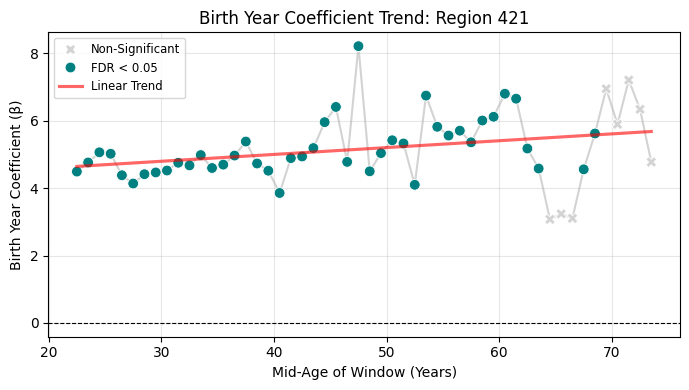

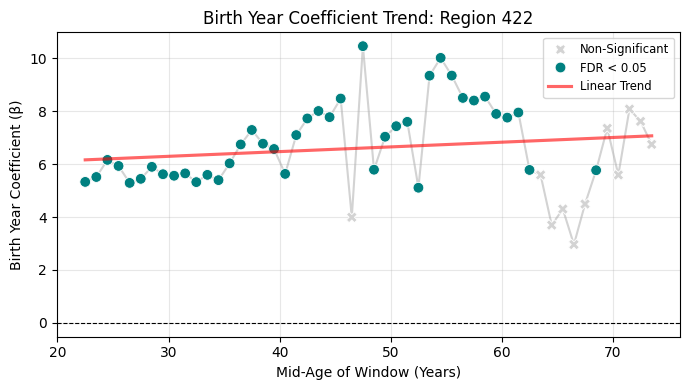

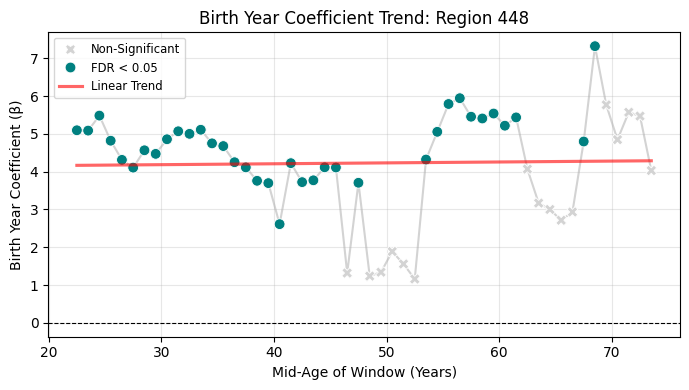

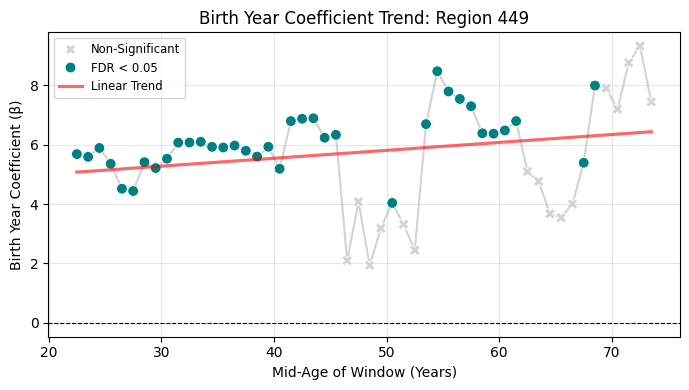

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Your specific ROIs
roi_list = [421, 422, 448, 449]

birth_year_coef_df = coef_df[coef_df['variable'] == 'birth_year']



for region_of_interest in roi_list:
    # Filter data for the specific ROI
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest].copy()
    
    if region_data.shape[0] < 2:
        print(f"Not enough data points for region {region_of_interest} to plot.")
        continue

    # 1. Add significance flag for coloring
    region_data['is_significant'] = region_data['fdr_p'] < 0.05
    
    # 2. Fit Linear Regression
    model = smf.ols('coef ~ age_median', data=region_data).fit()
    
    # 3. Plotting
    plt.figure(figsize=(7, 4))
    
    # Draw the gray connecting line first
    sns.lineplot(
        data=region_data,
        x='age_median',
        y='coef',
        color='lightgray',
        zorder=1,
        legend=False
    )
    
    # Draw colored markers on top
    # Significant = Teal/Blue, Non-significant = Gray
    sns.scatterplot(
        data=region_data,
        x='age_median',
        y='coef',
        hue='is_significant',
        palette={True: 'teal', False: 'lightgray'},
        style='is_significant',
        markers={True: 'o', False: 'X'},
        s=60,
        zorder=2
    )

    # Add the regression line
    sns.regplot(
        data=region_data,
        x='age_median',
        y='coef',
        scatter=False,
        ci=None,
        line_kws={'color': 'red', 'label': f'Trend (p={model.pvalues.iloc[1]:.3f})', 'alpha': 0.6},
        label='Linear Fit'
    )

    # Aesthetics
    plt.axhline(0, color='black', lw=0.8, ls='--') # Baseline
    plt.title(f'Birth Year Coefficient Trend: Region {region_of_interest}', fontsize=12)
    plt.xlabel('Mid-Age of Window (Years)')
    plt.ylabel('Birth Year Coefficient (β)')
    
    # Fix legend
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Non-Significant', 'FDR < 0.05', 'Linear Trend'], loc='best', fontsize='small')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()